# Tarefa

In [114]:
import numpy as np
import matplotlib.pyplot as plt

## A

In [115]:
# Lagrange

xi = np.array([-5., -1, 2, 8, 10, 17, 19, 24, 33, 36])
yi = np.array([2.1, 8.4, 15.7, 21.3, 17.6, 9.2, 14.8, 20.5, 11.3, 4.6])

n = xi.shape[0]

N = 100

# cria uma malha espalhando os pontos
x = np.linspace(xi[0], xi[n - 1], N)

ponto = 22

L = np.ones((n, N))

for i in range (0, n):
    for j in range (0, n):
        if i != j:
            L[i, :] *= (x - xi[j]) / (xi[i] - xi[j])

y = yi @ L

# calculando f(22)
n = len(x)
L = np.ones(n)

for i in range (0, n):
    for j in range (0, n):
        if i != j:
            L[i] = L[i] * (ponto - x[j] ) / (x[i] - x[j])

ponto_lagrange = y @ L
print (f"lagrange : ponto {ponto} : {ponto_lagrange}")

x_lagrange = x
y_lagrange = y

lagrange : ponto 22 : 22.596975727289617


In [116]:
# Newton

xi = np.array([-5., -1, 2, 8, 10, 17, 19, 24, 33, 36])
yi = np.array([2.1, 8.4, 15.7, 21.3, 17.6, 9.2, 14.8, 20.5, 11.3, 4.6])

n = xi.shape[0]

N = 100

x = np.linspace(xi[0], xi[n - 1], N)

D = np.zeros((n, n))

D[:, 0] = yi.T

# Calcula todas as diferenças Divididas
for j in range(1, n):
    for i in range (j, n):
        D[i,j] = (D[i, j-1] - D[i-1, j-1]) / (xi[i] - xi[i-j])

c = np.diag(D)

y = np.ones(N) * c[0] 

xv = np.ones(N)

for j in range (1, n):
    xv *= (x - xi[j-1])
    y = y + c[j] * xv


# calculando f(22)
x_v = 22
y_v = c[0]

xv_v = 1

for j in range (1, n):
    xv_v = xv_v * (x_v - xi[j-1])
    y_v = y_v + c[j] * xv_v
print(f"newton : ponto {x_v} : {y_v}")

x_newton = x
y_newton = y

newton : ponto 22 : 22.59697572728965


In [117]:
xi = np.array([-5., -1, 2, 8, 10, 17, 19, 24, 33, 36])
yi = np.array([2.1, 8.4, 15.7, 21.3, 17.6, 9.2, 14.8, 20.5, 11.3, 4.6])

n = xi.shape[0]

N = 100

x = np.linspace(xi[0], xi[n - 1], N)

m = n - 1

h = np.zeros(n-1)

for i in range (0, n-1):
    h[i] = xi[i+1] - xi[i]


a = yi
A = np.zeros((n, n))
r = np.zeros(n)

A[0,0] = 1
A[n-1,n-1] = 1

for j in range(1, n-1):
    A[j, j-1] = h[j-1]
    A[j, j] = 2 * h[j-1] + h[j]
    A[j, j+1] = h[j]
    r[j] = 3 * ((a[j+1] - a[j]) / h[j] - (a[j] - a[j-1]) / h[j-1])

c = np.linalg.solve(A, r)

d = np.zeros(m)

b = np.zeros(m)

for j in range (0, m):
    d[j] = (c[j+1] - c[j]) / (3 * h[j])
    b[j] = (a[j+1] - a[j]) / h[j] - h[j] / 3 * (2 * c[j] + c[j+1])


y = np.zeros(N)

for k in range (0, N):
    id = m
    for j in range (0, m):
        if x[k] <= xi[j+1]:
            id = j
            break
    t = x[k] - xi[id]
    y[k] = a[id] + b[id] * t + c[id] * t**2 + d[id] * t ** 3


# calculando f(22)

ponto = 22

n = len(x)

m = n - 1 

h = np.zeros(m)

for i in range(m):
    h[i] = x[i + 1] - x[i]

a = y

A = np.zeros((n, n))

r = np.zeros(n)

A[0, 0] = 1
A[n - 1, n - 1] = 1

for j in range(1, n - 1):
    A[j, j - 1] = h[j - 1]
    A[j, j] = 2 * (h[j - 1] + h[j])
    A[j, j + 1] = h[j]
    r[j] = 3 * (((a[j+1] - a[j]) / h[j]) - ((a[j] - a[j-1]) / h[j-1]))

c = np.linalg.solve(A, r)

idx = 0

for j in range(0, m):
    if ponto <= x[j + 1]:
        idx = j
        break

d = (c[idx + 1] - c[idx]) / (3 * h[idx])

b = ((a[idx + 1] - a[idx]) / h[idx]) - ((h[idx] / 3) * (2 * c[idx] + c[idx + 1]))

t = ponto - x[idx]

ponto_spline = a[idx] + b * t + c[idx] * (t**2) + d * (t**3)

print(f"spline cúbico : ponto {ponto} : {ponto_spline}")


x_spline = x
y_spline = y

spline cúbico : ponto 22 : 20.535932766495915


## B

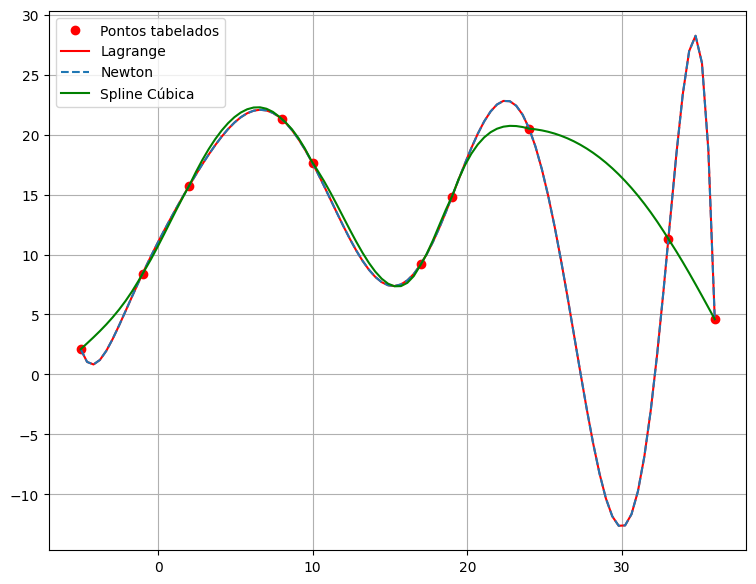

In [121]:
xi = np.array([-5., -1, 2, 8, 10, 17, 19, 24, 33, 36])
yi = np.array([2.1, 8.4, 15.7, 21.3, 17.6, 9.2, 14.8, 20.5, 11.3, 4.6])

plt.figure(figsize=(9, 7))
plt.plot(xi, yi, 'ro', label='Pontos tabelados')
plt.plot(x_lagrange, y_lagrange, 'r-', label='Lagrange')
plt.plot(x_newton, y_newton, '--', label='Newton')
plt.plot(x_spline, y_spline, 'g-', label='Spline Cúbica')
plt.grid()
plt.legend()
plt.show()

Comparando as curvas:

As curvas de Lagrange e Newton são iguais, pois seus métodos chegam ao mesmo resultado (interpolador único). Ou seja, são caminhos distintos para chegar no mesmo resultado.

Nos gráficos de Lagrange e Newton, há oscilações fortes (principalmente no intervalo [21, 35]). Isso ocorre por causa do Fenômeno de Runge, pois os métodos tentam "passar a linha (o polinômio)" por todos os pontos do gráfico. 

Dai vem o Spline, uma solução ótima para o Fenômeno de Runge, que consegue suavizar a linha (é visível no gráfico que não há oscilações iguais as que os métodos anteriores geraram).

## C

In [ ]:
Lagrange_y_min = min(y_lagrange)
Lagrange_x_min = x_lagrange[np.argmin(y_lagrange)]
Lagrange_y_max = max(y_lagrange)
Lagrange_x_max = x_lagrange[np.argmax(y_lagrange)]



Newton_y_min = min(y_newton)
Newton_x_min = x_newton[np.argmin(y_newton)]
Newton_y_max = max(y_newton)
Newton_x_max = x_newton[np.argmax(y_newton)]


Spline_y_min = min(y_spline)
Spline_x_min = x_spline[np.argmin(y_spline)]
Spline_y_max = max(y_spline)
Spline_x_max = x_spline[np.argmax(y_spline)]





print(f"Lagrange ||| x_min = {Lagrange_x_min} f(x_min) = {Lagrange_y_min} ||| x_max = {Lagrange_x_max} f(x_max) = {Lagrange_y_max}")
print(f"Newton ||| x_min = {Newton_x_min} f(x_min) = {Newton_y_min} ||| x_max = {Newton_x_max} f(x_max) = {Newton_y_max}")
print(f"Spline ||| x_min = {Spline_x_min} f(x_min) = {Spline_y_min} ||| x_max = {Spline_x_max} f(x_max) = {Spline_y_max}")

Lagrange ||| x_min = 29.78787878787879 f(x_min) = -12.62882000045959 ||| x_max = 34.75757575757576 f(x_max) = 28.247088553253946
Newton ||| x_min = 29.78787878787879 f(x_min) = -12.628820000459406 ||| x_max = 34.75757575757576 f(x_max) = 28.247088553254002
Spline ||| x_min = -5.0 f(x_min) = 2.1 ||| x_max = 6.595959595959595 f(x_max) = 22.279388397178714
